### EXPLORING THE DATA: DATA ANALYSIS

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
data_frame = pd.read_csv(r"C:\Users\Ifeoluwa\OneDrive\Documents\Nexora_Care\data\processed\cleaned_appointments.csv")


In [11]:
data_frame.head()

,AppointmentID,ClinicID,ClinicName,ClinicType,PatientID,ProviderID,AppointmentDateTime,AppointmentType,Status,BookingChannel,BookingLeadTimeDays,IsHoliday,HolidayName,SeasonFlag,ChronicConditionFlag
0,529385,2,Nexora Care - Lakeside,Multi-Specialty,103642,202,2024-01-01 08:00,New Patient,Completed,Online,2,True,New Year's Day,Flu Season,False
1,500000,1,Nexora Care - Riverside,Primary Care,101551,101,2024-01-01 08:30,New Patient,No-Show,Online,18,True,New Year's Day,Flu Season,False
2,500011,1,Nexora Care - Riverside,Primary Care,100260,104,2024-01-01 08:30,Follow-Up,Completed,Referral,4,True,New Year's Day,Flu Season,False
3,575066,3,Nexora Care - Downtown Express,Telehealth-Forward,104923,301,2024-01-01 09:45,Urgent,Completed,Online,0,True,New Year's Day,Flu Season,False
4,500008,1,Nexora Care - Riverside,Primary Care,101124,104,2024-01-01 09:45,Telehealth,Completed,Phone,2,True,New Year's Day,Flu Season,False


In [6]:
data_frame['AppointmentDateTime'] = pd.to_datetime(data_frame['AppointmentDateTime'])

In [7]:
data_frame['Status'].value_counts()

Status
Completed      109040
No-Show         11367
Cancelled        6296
Rescheduled      2650
Name: count, dtype: int64

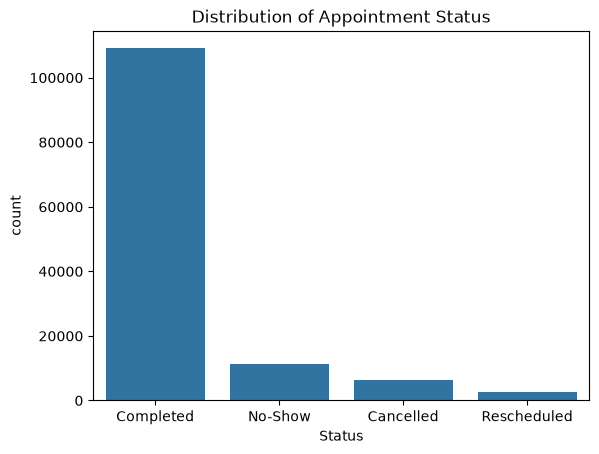

In [12]:
sns.countplot(data=data_frame, x='Status', order=data_frame['Status'].value_counts().index)
plt.title('Distribution of Appointment Status')
plt.show()

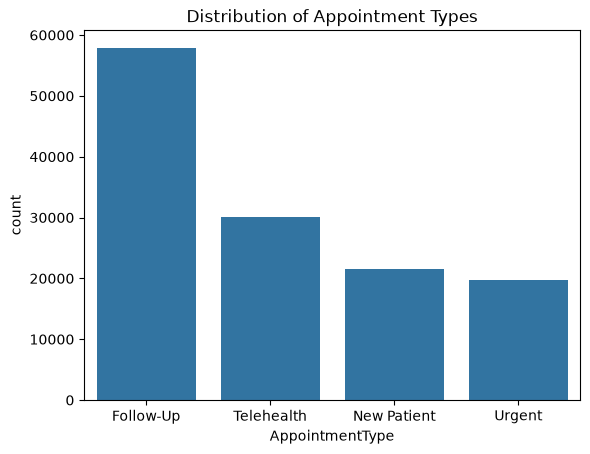

In [13]:
sns.countplot(data=data_frame, x='AppointmentType', order=data_frame['AppointmentType'].value_counts().index)
plt.title('Distribution of Appointment Types')
plt.show()

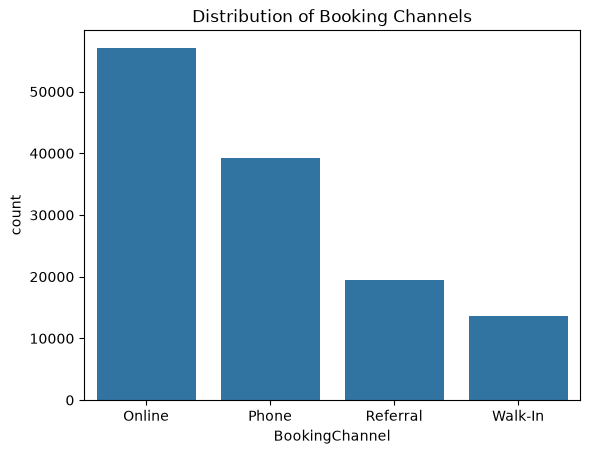

In [14]:
sns.countplot(data=data_frame, x='BookingChannel', order=data_frame['BookingChannel'].value_counts().index)
plt.title('Distribution of Booking Channels')
plt.show()

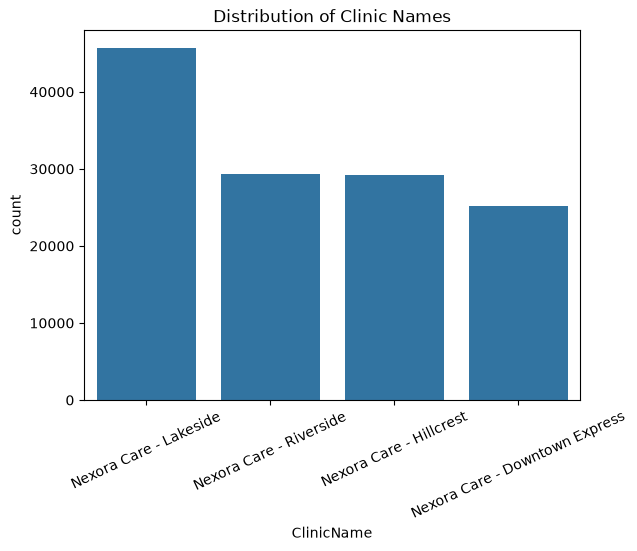

In [17]:
sns.countplot(data=data_frame, x='ClinicName', order=data_frame['ClinicName'].value_counts().index)
plt.title('Distribution of Clinic Names')
plt.xticks(rotation=25)
plt.show()

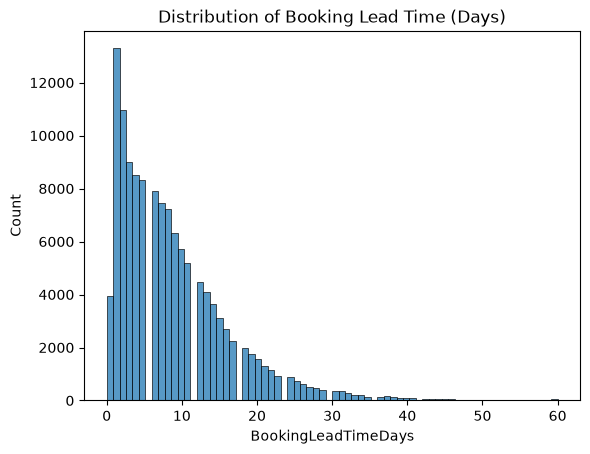

In [21]:
sns.histplot(data=data_frame, x='BookingLeadTimeDays', bins=70)
plt.title('Distribution of Booking Lead Time (Days)')
plt.show()

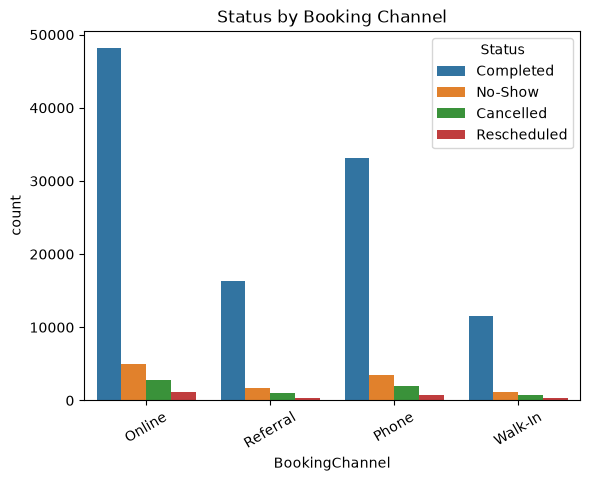

In [26]:
sns.countplot(data=data_frame, x='BookingChannel', hue='Status')
plt.title('Status by Booking Channel')
plt.xticks(rotation=30)
plt.show()

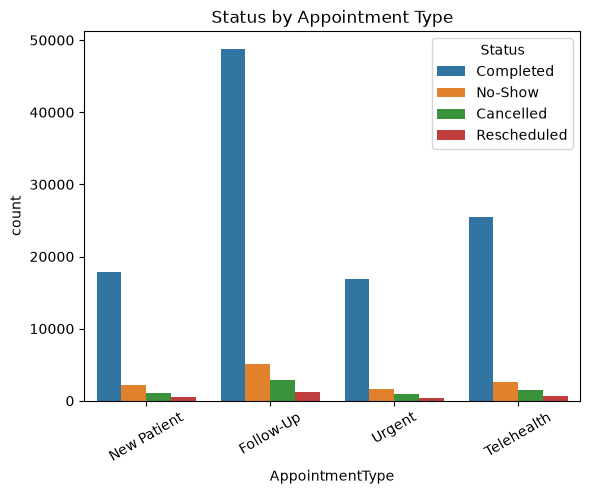

In [28]:
sns.countplot(data=data_frame, x='AppointmentType', hue='Status')
plt.title('Status by Appointment Type')
plt.xticks(rotation=30)
plt.show()

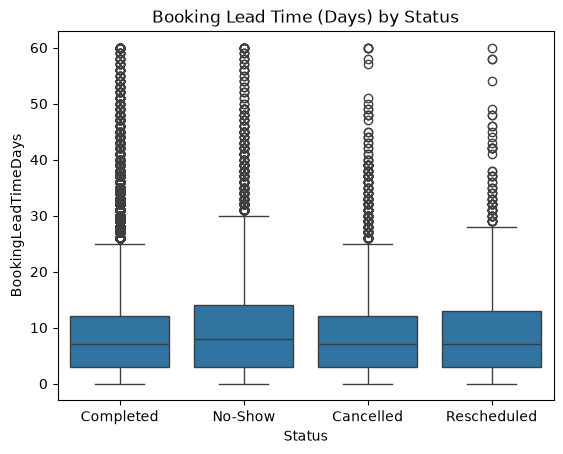

In [32]:
sns.boxplot(data=data_frame, x='Status', y='BookingLeadTimeDays')
plt.title('Booking Lead Time (Days) by Status')
plt.show()

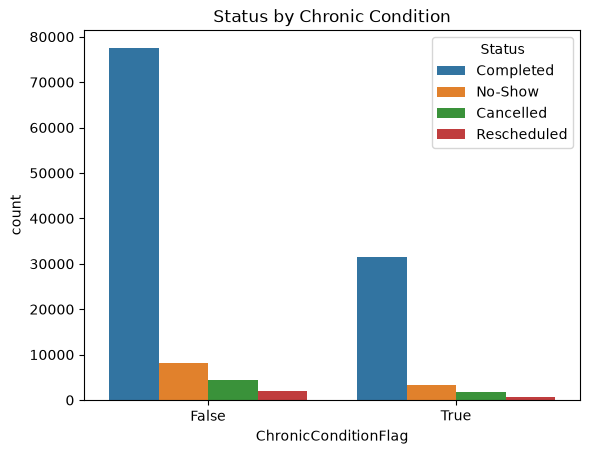

In [33]:
sns.countplot(data=data_frame, x='ChronicConditionFlag', hue='Status')
plt.title('Status by Chronic Condition')
plt.show()

In [34]:
data_frame.info()

<class 'pandas.DataFrame'>
RangeIndex: 129353 entries, 0 to 129352
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   AppointmentID         129353 non-null  int64
 1   ClinicID              129353 non-null  int64
 2   ClinicName            129353 non-null  str  
 3   ClinicType            129353 non-null  str  
 4   PatientID             129353 non-null  int64
 5   ProviderID            129353 non-null  int64
 6   AppointmentDateTime   129353 non-null  str  
 7   AppointmentType       129353 non-null  str  
 8   Status                129353 non-null  str  
 9   BookingChannel        129353 non-null  str  
 10  BookingLeadTimeDays   129353 non-null  int64
 11  IsHoliday             129353 non-null  bool 
 12  HolidayName           129353 non-null  str  
 13  SeasonFlag            129353 non-null  str  
 14  ChronicConditionFlag  129353 non-null  bool 
dtypes: bool(2), int64(5), str(8)
memory usage: 13

In [36]:
data_frame['AppointmentDateTime'] = pd.to_datetime(data_frame['AppointmentDateTime'])

In [37]:
data_frame.info()

<class 'pandas.DataFrame'>
RangeIndex: 129353 entries, 0 to 129352
Data columns (total 15 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   AppointmentID         129353 non-null  int64         
 1   ClinicID              129353 non-null  int64         
 2   ClinicName            129353 non-null  str           
 3   ClinicType            129353 non-null  str           
 4   PatientID             129353 non-null  int64         
 5   ProviderID            129353 non-null  int64         
 6   AppointmentDateTime   129353 non-null  datetime64[us]
 7   AppointmentType       129353 non-null  str           
 8   Status                129353 non-null  str           
 9   BookingChannel        129353 non-null  str           
 10  BookingLeadTimeDays   129353 non-null  int64         
 11  IsHoliday             129353 non-null  bool          
 12  HolidayName           129353 non-null  str           
 13  SeasonFlag

In [45]:
daily_data = data_frame.set_index('AppointmentDateTime').resample('D').size()
daily_data

AppointmentDateTime
2024-01-01     31
2024-01-02    221
2024-01-03    167
2024-01-04    171
2024-01-05    103
             ... 
2025-12-27    153
2025-12-28     25
2025-12-29    332
2025-12-30    325
2025-12-31     51
Freq: D, Length: 731, dtype: int64

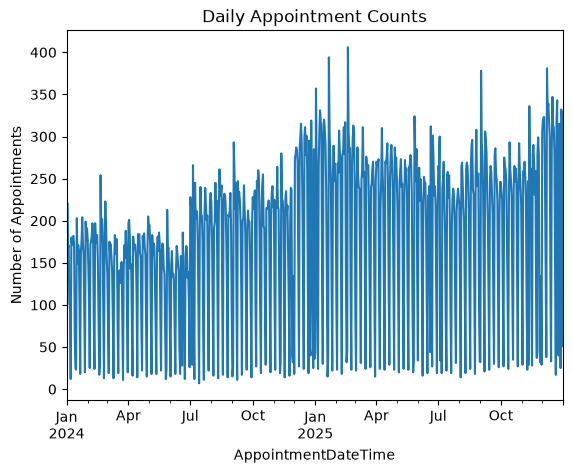

In [47]:
daily_data.plot()
plt.title('Daily Appointment Counts')
plt.ylabel('Number of Appointments')
plt.show()

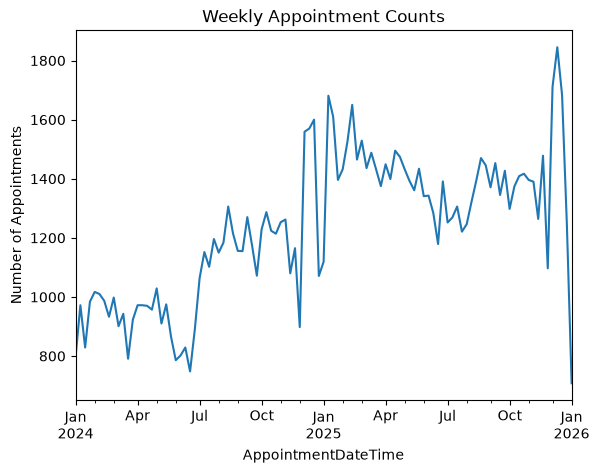

In [48]:
weekly_data = data_frame.set_index('AppointmentDateTime').resample('W').size()
weekly_data
weekly_data.plot()
plt.title('Weekly Appointment Counts')
plt.ylabel('Number of Appointments')
plt.show()

In [49]:
data_frame.groupby('IsHoliday').size()

IsHoliday
False    128414
True        939
dtype: int64

In [50]:
data_frame.groupby('HolidayName').size()

HolidayName
Christmas Day                 80
Christmas Eve                105
Day After Thanksgiving        64
Independence Day              63
Juneteenth                    72
Labor Day                     58
MLK Day                       59
Memorial Day                  58
New Year's Day                74
New Year's Eve                87
No Holiday                128414
Presidents' Day               73
Thanksgiving                  87
Veterans Day                  59
dtype: int64

In [51]:
data_frame['AppointmentDateTime'].dt.day_name().value_counts()

AppointmentDateTime
Tuesday      25350
Wednesday    24191
Thursday     22981
Monday       22248
Friday       21315
Saturday     11057
Sunday        2211
Name: count, dtype: int64

In [53]:
data_frame.to_csv(r"C:\Users\Ifeoluwa\OneDrive\Documents\Nexora_Care\data\processed\eda_appointments.csv", index=False)